In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Setup
## PyTorch Tensors
### Tensor Question 1
### Tensor Question 2
### Tensor Question 3
### Tensor Question 4
### Tensor Question 5

## Pretrained Models
### Model Question 1
### Model Question 2
### Model Question 3
### Model Question 4

## Running Inference
### Inference Question 1
### Inference Question 2
### Inference Question 3
### Inference Question 4

In [1]:
import os
os.makedirs("outputs", exist_ok=True)

import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Using device: cuda
PyTorch version:     2.10.0+cu128
TorchVision version: 0.25.0+cu128


## PyTorch Tensors

### Tensor Question 1

In [2]:
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

b = torch.zeros(2, 3)
c = torch.ones(4)

for name, tensor in [("a", a), ("b", b), ("c", c)]:
    print(f"\n{name}:")
    print(tensor)
    print("Shape:", tensor.shape)
    print("Dtype:", tensor.dtype)
    print("Device:", tensor.device)

# Comment:
# These tensors are on the CPU right now.
# If running a training loop on GPU, the model weights and input tensors must be on the same device.
# This matters because PyTorch cannot calculate between CPU tensors and GPU tensors together.


a:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
Shape: torch.Size([2, 3])
Dtype: torch.float32
Device: cpu

b:
tensor([[0., 0., 0.],
        [0., 0., 0.]])
Shape: torch.Size([2, 3])
Dtype: torch.float32
Device: cpu

c:
tensor([1., 1., 1., 1.])
Shape: torch.Size([4])
Dtype: torch.float32
Device: cpu


### Tensor Question 2


In [3]:
x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])

print("Square root:", torch.sqrt(x))
print("Sum:", x.sum())
print("Mean:", x.mean())
print("Index of max value:", x.argmax())

# Comment:
# torch.sqrt(x) gives the square root of each number.
# x.sum() adds all numbers together.
# x.mean() gives the average.
# x.argmax() gives the index/position of the biggest value.
# In a classifier with 1,000 class scores, argmax gives the class index with the highest score.

Square root: tensor([1., 2., 3., 4., 5.])
Sum: tensor(55.)
Mean: tensor(11.)
Index of max value: tensor(4)


### Tensor Question 3

In [4]:
a_gpu = a.to(device)
print(f"a_gpu device: {a_gpu.device}")

a_back = a_gpu.cpu()
a_numpy = a_back.numpy()

print(f"numpy type: {type(a_numpy)}")
print(f"numpy values:\n{a_numpy}")

# Comment:
# PyTorch requires .cpu() before .numpy() because NumPy arrays live on the CPU.
# NumPy cannot directly use a tensor that is stored on the GPU.
# So we move the tensor back to CPU first, then convert it to a NumPy array.

a_gpu device: cuda:0
numpy type: <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]


### Tensor Question 4

In [5]:
t = torch.arange(24).float()

t1 = t.reshape(4, 6)
print("Shape after reshape to (4, 6):", t1.shape)

t2 = t.reshape(2, 3, 4)
print("Shape after reshape to (2, 3, 4):", t2.shape)

t3 = t1.unsqueeze(0)
print("Shape after adding new dimension:", t3.shape)

# Comment:
# reshape changes the shape of the tensor while keeping the same numbers.
# unsqueeze(0) adds a new dimension at the front.
# A single image usually has shape (channels, height, width).
# A neural network expects a batch shape: (batch_size, channels, height, width).
# So unsqueeze(0) is used when processing one image because it makes one image into a batch of one image.

Shape after reshape to (4, 6): torch.Size([4, 6])
Shape after reshape to (2, 3, 4): torch.Size([2, 3, 4])
Shape after adding new dimension: torch.Size([1, 4, 6])


### Tensor Question 5

In [6]:
np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])

t_a = torch.tensor(np_a, dtype=torch.float32)
t_b = torch.tensor(np_b, dtype=torch.float32)

np_result = np_a @ np_b
torch_result = t_a @ t_b

print("NumPy result:")
print(np_result)

print("\nPyTorch result:")
print(torch_result)

print("\nDo they match?")
print(np.allclose(np_result, torch_result.numpy()))

# Comment:
# Matrix multiplication is one of the main calculations inside neural networks.
# A neural network layer multiplies input data by learned weights.
# This helps the model transform raw input numbers into useful patterns and predictions.

NumPy result:
[[19. 22.]
 [43. 50.]]

PyTorch result:
tensor([[19., 22.],
        [43., 50.]])

Do they match?
True


## Pretrained Models

### Model Question 1

In [7]:
weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Comment:
# ResNet18 has roughly 11 million parameters.
# Training a model like this from scratch needs a huge image dataset and a lot of GPU time.
# Pretrained weights are useful because the model already learned general image patterns.
# This saves time, money, data, and computing power when working on a deadline or budget.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


Total parameters:     11,689,512
Trainable parameters: 11,689,512


### Model Question 2

In [8]:
print(model)

# Comment:
# The final layer is named fc.
# Its output size is 1000, because ImageNet has 1000 categories.
# The blocks named layer1, layer2, layer3, and layer4 are the deeper feature extractor parts of ResNet18.
# In simple terms, "deep" means the network has many layers.
# Early layers learn simple patterns like edges and colors.
# Deeper layers learn more complex patterns like shapes, textures, and object parts.

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Model Question 3

In [9]:
model = model.to(device)
model.eval()
print("Model ready for inference.")

# Comment:
# model.to(device) moves the model to the GPU if device is cuda.
# This matters because the input image tensor will also be moved to the same device.
# The model and the input tensor must be on the same device, or PyTorch will give an error.
#
# model.eval() puts the model in evaluation mode.
# This means we are using the model for prediction, not training.
# Some layers behave differently in training mode and evaluation mode.
# Examples: Dropout and BatchNorm behave differently during training vs. evaluation.

Model ready for inference.


### Model Question 4

In [10]:
preprocess = weights.transforms()
print(preprocess)

# Comment:
# This preprocessing pipeline prepares images the same way ResNet18 saw images during training.
#
# Resize/crop:
# It changes the image to the correct size for the model.
# ResNet18 expects images around 224 x 224 pixels.
#
# ToTensor:
# It converts the image into a PyTorch tensor.
# It also changes pixel values from 0-255 into decimal values between 0 and 1.
#
# Normalization:
# It adjusts the image numbers using ImageNet's mean and standard deviation.
# This matters because ResNet18 was trained using ImageNet-normalized images.
# If we use different normalization, the model may make worse predictions.

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


## Running Inference

In [11]:
import random
random.seed(42)

DATA_DIR = Path("/kaggle/input/intel-image-classification/seg_test/seg_test")
LABELS = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def load_sample_image(label):
    """Load a random image file from the given class folder."""
    class_dir = DATA_DIR / label
    img_path = random.choice(list(class_dir.glob("*.jpg")))
    return Image.open(img_path).convert("RGB"), img_path.name

imagenet_classes = weights.meta["categories"]
print(f"Number of classes: {len(imagenet_classes)}")
print(f"First 5 labels: {imagenet_classes[:5]}")

Number of classes: 1000
First 5 labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


### Inference Question 1

In [12]:
def get_top5_predictions(model, preprocess, image, device, class_labels):
    """
    Run inference on a PIL image and return the top-5 predictions.
    Returns a list of (class_name, probability) tuples.
    """

    # Step 1: Preprocess the image and add a batch dimension
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    # Step 2: Run inference without training
    with torch.no_grad():
        output = model(input_tensor)

    # Step 3: Convert raw scores/logits to probabilities
    probabilities = torch.nn.functional.softmax(output[0], dim=0)

    # Step 4: Get the top 5 probabilities and class indexes
    top_probs, top_indices = torch.topk(probabilities, 5)

    # Step 5: Build the final list of class names and probabilities
    results = []
    for prob, index in zip(top_probs, top_indices):
        class_name = class_labels[index.item()]
        results.append((class_name, prob.item()))

    return results

In [13]:
img, img_name = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}':")
for class_name, prob in preds:
    print(f"  {class_name:30s}  {prob:.4f}")

# Comment:
# The top prediction may or may not say exactly "mountain".
# ResNet18 was trained on ImageNet, which has 1000 labels such as alp, valley, lakeside, cliff, and volcano.
# So if the top-5 predictions are related to outdoor or mountain scenes, the prediction makes sense.

IndexError: Cannot choose from an empty sequence

In [14]:
from pathlib import Path

base = Path("/kaggle/input")
print("Folders inside /kaggle/input:")
for p in base.iterdir():
    print(p)

Folders inside /kaggle/input:
/kaggle/input/notebooks


In [15]:
from pathlib import Path

print("Folders inside /kaggle/input:")
for p in Path("/kaggle/input").iterdir():
    print(p)

Folders inside /kaggle/input:
/kaggle/input/notebooks
/kaggle/input/datasets


In [16]:
from pathlib import Path

datasets_dir = Path("/kaggle/input/datasets")

print("Inside /kaggle/input/datasets:")
for p in datasets_dir.iterdir():
    print(p)

Inside /kaggle/input/datasets:
/kaggle/input/datasets/puneet6060


In [17]:
from pathlib import Path

puneet_dir = Path("/kaggle/input/datasets/puneet6060")

print("Inside puneet6060:")
for p in puneet_dir.iterdir():
    print(p)

Inside puneet6060:
/kaggle/input/datasets/puneet6060/intel-image-classification


In [18]:
print("Searching for seg_test folders...")

for p in Path("/kaggle/input/datasets/puneet6060").rglob("seg_test"):
    print(p)

Searching for seg_test folders...
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test


In [19]:
DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

print("DATA_DIR exists?", DATA_DIR.exists())

for folder in DATA_DIR.iterdir():
    print(folder.name, "=", len(list(folder.glob("*.jpg"))), "images")

DATA_DIR exists? True
mountain = 525 images
street = 501 images
buildings = 437 images
sea = 510 images
forest = 474 images
glacier = 553 images


In [21]:
def load_sample_image(label):
    """Load a random image file from the given class folder."""
    class_dir = DATA_DIR / label
    img_path = random.choice(list(class_dir.glob("*.jpg")))
    return Image.open(img_path).convert("RGB"), img_path.name

In [22]:
img, img_name = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}':")
for class_name, prob in preds:
    print(f"  {class_name:30s}  {prob:.4f}")

# Comment:
# The top prediction may or may not say exactly "mountain".
# ResNet18 was trained on ImageNet, which has 1000 labels such as alp, valley, lakeside, cliff, and volcano.
# If the top-5 labels are related to outdoor or mountain scenes, the prediction still makes sense.


Top-5 predictions for '24204.jpg':
  alp                             0.4911
  volcano                         0.2076
  valley                          0.2016
  promontory                      0.0184
  mountain tent                   0.0169


### Inference Question 2

In [23]:
for label in LABELS:
    img, img_name = load_sample_image(label)
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]

    print(f"\n[{label}]  {img_name}")
    for class_name, prob in preds:
        print(f"  {class_name:30s}  {prob:.4f}")

# Comment:
# The model is most confident when the top-1 probability is high.
# The model is least confident when the top-1 probability is low.
# Some predictions may not exactly match buildings, forest, glacier, mountain, sea, and street
# because ResNet18 was trained on ImageNet's 1000 labels, not these six exact scene labels.


[buildings]  24258.jpg
  palace                          0.4301
  gondola                         0.1305
  monastery                       0.0624

[forest]  23309.jpg
  viaduct                         0.3853
  totem pole                      0.1089
  cliff                           0.0419

[glacier]  20272.jpg
  volcano                         0.3854
  valley                          0.3297
  promontory                      0.1216

[mountain]  20662.jpg
  ski                             0.5933
  alp                             0.3821
  snowmobile                      0.0071

[sea]  23069.jpg
  seashore                        0.2016
  breakwater                      0.1834
  geyser                          0.1718

[street]  24269.jpg
  unicycle                        0.1299
  triumphal arch                  0.1268
  jinrikisha                      0.1049


### Inference Question 3

In [25]:
img, _ = load_sample_image("forest")
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

probs = torch.nn.functional.softmax(logits[0], dim=0)

print(f"Logit  range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob   range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")
print(f"Top prediction: {imagenet_classes[probs.argmax().item()]}  ({probs.max():.4f})")

# Comment:
# Logits are the raw scores from the model before softmax.
# They can be negative or positive and do not have to add up to 1.
# Softmax changes logits into probabilities.
# Probabilities are easier to understand because they are between 0 and 1 and sum to 1.
# In a production pipeline, I would use probabilities to filter low-confidence predictions.
# For example, if the top probability is too low, I would send the image to a human reviewer.

Logit  range: min=-4.84, max=7.08
Prob   range: min=0.000001, max=0.1689
Probs sum to: 1.000000
Top prediction: worm fence  (0.1689)


### Inference Question 4

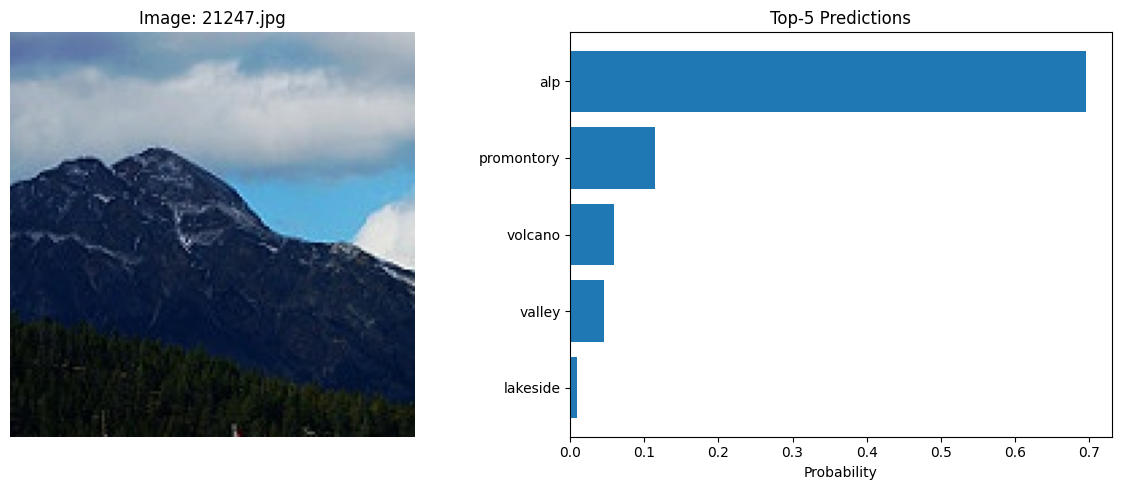

In [26]:
img, img_name = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

class_names = [p[0] for p in preds]
probabilities = [p[1] for p in preds]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img)
axes[0].set_title(f"Image: {img_name}")
axes[0].axis("off")

axes[1].barh(class_names, probabilities)
axes[1].invert_yaxis()
axes[1].set_xlabel("Probability")
axes[1].set_title("Top-5 Predictions")

plt.tight_layout()
plt.savefig("outputs/warmup_inference_viz.png")
plt.show()

# Comment:
# For a dashboard, I would show the image, the top prediction,
# the confidence score, and a warning label if confidence is low.
# A non-technical team member should be able to quickly see:
# what the image is, what the model predicted, and how confident the model was.
#
# I might use 0.60 as a starting confidence threshold.
# If the top-1 probability is below 0.60, the dashboard could flag the image
# for human review instead of automatically accepting the prediction.

In [27]:
import os

print(os.path.exists("outputs/warmup_inference_viz.png"))

True
